<a href="https://colab.research.google.com/github/rachitamurugan/Retail-DemandForecasting/blob/main/RetailDemand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Retail Demand Forecasting**

In [12]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/FMCG_2022_2024.csv", parse_dates=["date"])

# Basic cleaning
df = df.dropna(subset=["units_sold", "Sales"])
df["units_sold"] = df["units_sold"].astype(float)
df["Sales"] = df["Sales"].astype(float)

# Feature engineering
df["date"] = df["date"]
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

# Lag features
df["sales_lag_1"] = df["Sales"].shift(1)
df["sales_lag_7"] = df["Sales"].shift(7)

# Rolling averages
df["sales_roll_7"] = df["Sales"].rolling(7).mean()
df["sales_roll_30"] = df["Sales"].rolling(30).mean()

In [13]:
print(df.columns)

Index(['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region',
       'pack_type', 'price_unit', 'promotion_flag', 'delivery_days',
       'stock_available', 'delivered_qty', 'units_sold', 'Sales',
       'day_of_week', 'month', 'year', 'sales_lag_1', 'sales_lag_7',
       'sales_roll_7', 'sales_roll_30'],
      dtype='object')


Seasonality Analysis

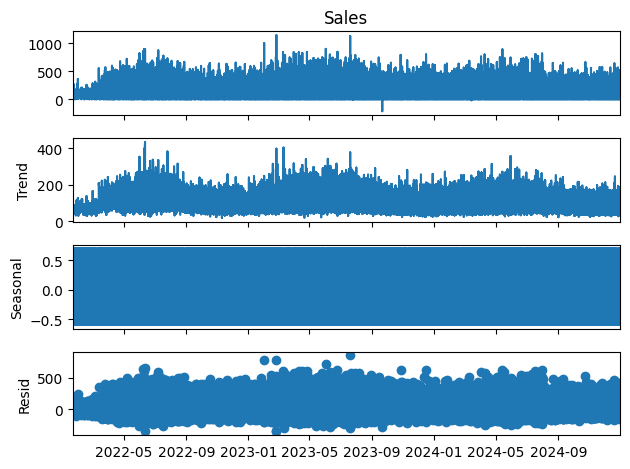

In [14]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Decompose time series
df = df.set_index("date")
decomposition = sm.tsa.seasonal_decompose(df["Sales"], model="additive", period=7)
decomposition.plot()
plt.show()

Promotion Impact

Average Sales with vs without Promotion:
 promotion_flag
0     91.498437
1    179.244239
Name: Sales, dtype: float64


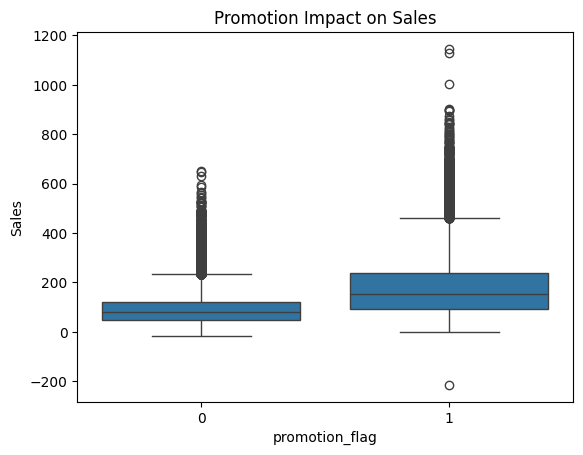

In [16]:
import seaborn as sns

# Assume 'promotion' column exists (1 if promo active, else 0)
promo_sales = df.groupby("promotion_flag")["Sales"].mean()
print("Average Sales with vs without Promotion:\n", promo_sales)

sns.boxplot(x="promotion_flag", y="Sales", data=df)
plt.title("Promotion Impact on Sales")
plt.show()

Price Elasticity

In [20]:
import statsmodels.formula.api as smf

# Regression: sales vs price
model = smf.ols("units_sold ~ price_unit", data=df).fit()
print(model.summary())

# Elasticity = (ΔQ/Q) / (ΔP/P)
elasticity = model.params["price_unit"] * (df["price_unit"].mean() / df["units_sold"].mean())
print("Price Elasticity of Demand:", elasticity)

                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2260
Date:                Fri, 12 Jun 2026   Prob (F-statistic):              0.635
Time:                        10:52:19   Log-Likelihood:            -7.4099e+05
No. Observations:              190757   AIC:                         1.482e+06
Df Residuals:                  190755   BIC:                         1.482e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.9508      0.071    282.336      0.0

In [ ]:
Prophet Forecasting (Seasonality + Holidays)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


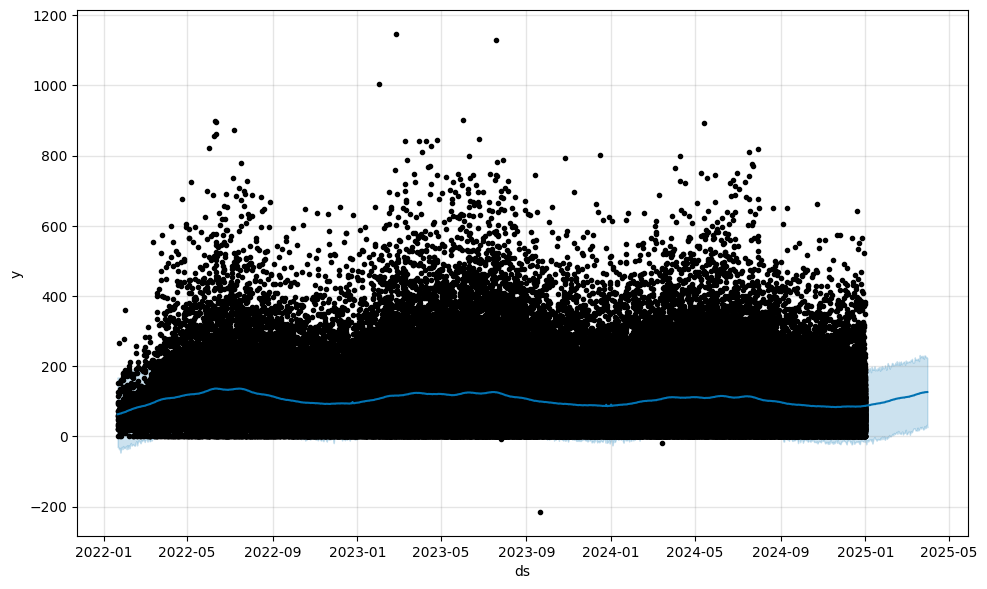

In [23]:
from prophet import Prophet

# Prepare dataset for Prophet
df_prophet = df.reset_index()[["date","Sales"]].rename(columns={"date":"ds","Sales":"y"})

# Add holiday dataframe if available
holidays = pd.DataFrame({
    'holiday': 'festival',
    'ds': pd.to_datetime(['2022-12-25','2023-12-25','2024-01-01']),
    'lower_window': 0,
    'upper_window': 1,
})

# Train Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, holidays=holidays)
model.fit(df_prophet)

# Forecast next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.show()

In [ ]:
Inventory Optimization & Promotion Strategy Insights

In [24]:
# Example: Safety Stock & Reorder Point
residuals = df_prophet["y"] - forecast["yhat"][:len(df_prophet)]
sigma = np.std(residuals)

Z = 1.65   # 95% service level
lead_time = 2   # weeks
forecasted_demand = df_prophet["y"].mean()

safety_stock = Z * sigma * np.sqrt(lead_time)
reorder_point = forecasted_demand * lead_time + safety_stock

print("Safety Stock:", safety_stock)
print("Reorder Point:", reorder_point)

# Promotion Strategy Simulation
uplift = promo_sales[1] - promo_sales[0]
print("Average Sales Uplift during Promotions:", uplift)

Safety Stock: 144.69629107141077
Reorder Point: 353.87656314530585
Average Sales Uplift during Promotions: 87.7458028020214
